# Introduction to Analytical Tables

The cron process makes a number of tables available for analysis. These tables are updated at the beginning of each day. 

| Table      | Description      |
| ------------- | ------------- |
| sensor_readings | The most "raw" data from the Coris API. One row per Sensor and UTC timestamp. Devices have 2 Sensors, one for Temperature and one for Humidity so each Device will typically have two rows per UTC timestamp. |
| device_readings | Sensor readings reorganized to one row per Device and UTC timestamp, with Sensor measurements across columns instead of rows. |
| sensors | Information about the unique sensors. One row per SensorID_Coris. Includes information extracted from SensorName. Join this to sensor_readings during analysis to enhance with Building, Room, Direction, etc. |
| devices | Information about unique devices. One row per DeviceID_Coris. Includes information extracted from SensorName. Join this to device_readings during analysis to enhance with Building, Room, Direction, etc. |
| utcs | Information related to the UTC times in various datasets. Join to sensor_readings or device_readings to enhance with Date, Time, Year, Hour, Weekday, etc. |
| sensor_readings_daily | Example of sensor readings summarized to the daily level which reduces row count by 99.3% for even faster queries. You can create different cubes to support common analysis patterns. |
| device_readings_daily | Example of device readings summarized to the daily level. |

Let's take a look at each of the tables. 

In [1]:
import duckdb
duckdb.sql("SELECT * FROM read_parquet('data/sensor_readings.parquet') LIMIT 5").df()

,SensorReadingUTC,Source,DeviceID,DeviceName,SensorID,SensorName,SensorType,SensorReadingF,SensorReadingRh,QueryUTC,SensorReadingUTC_SecondsFromPrior
0,1699294335,Coris,coris:12162,Peabody TH-L Mammal Hall D444,coris:21373,PYPM__0100104SET____ Temp YPM 104_D444,Temperature,69.639999,NaN,<NA>,<NA>
1,1699294935,Coris,coris:12162,Peabody TH-L Mammal Hall D444,coris:21373,PYPM__0100104SET____ Temp YPM 104_D444,Temperature,69.620003,NaN,<NA>,600
2,1699295535,Coris,coris:12162,Peabody TH-L Mammal Hall D444,coris:21373,PYPM__0100104SET____ Temp YPM 104_D444,Temperature,69.580002,NaN,<NA>,600
3,1699296135,Coris,coris:12162,Peabody TH-L Mammal Hall D444,coris:21373,PYPM__0100104SET____ Temp YPM 104_D444,Temperature,69.580002,NaN,<NA>,600
4,1699296735,Coris,coris:12162,Peabody TH-L Mammal Hall D444,coris:21373,PYPM__0100104SET____ Temp YPM 104_D444,Temperature,69.639999,NaN,<NA>,600


In [2]:
duckdb.sql("SELECT * FROM read_parquet('data/device_readings.parquet') LIMIT 5").df()

,Source,DeviceID,DeviceName,Sensors,SensorNames,SensorTypes,SensorReadingUTC,QueryUTC,SensorReadingF,SensorReadingRh
0,Coris,coris:12162,Peabody TH-L Mammal Hall D444,"coris:21374, coris:21373","PYPM__0100104SET____ RH YPM 104_D444 , PYPM__0...","Humidity, Temperature",1699294335,<NA>,NaN,50.049999
1,Coris,coris:12162,Peabody TH-L Mammal Hall D444,"coris:21374, coris:21373","PYPM__0100104SET____ RH YPM 104_D444 , PYPM__0...","Humidity, Temperature",1699294935,<NA>,NaN,50.200001
2,Coris,coris:12162,Peabody TH-L Mammal Hall D444,"coris:21374, coris:21373","PYPM__0100104SET____ RH YPM 104_D444 , PYPM__0...","Humidity, Temperature",1699295535,<NA>,NaN,50.240002
3,Coris,coris:12162,Peabody TH-L Mammal Hall D444,"coris:21374, coris:21373","PYPM__0100104SET____ RH YPM 104_D444 , PYPM__0...","Humidity, Temperature",1699296135,<NA>,NaN,50.240002
4,Coris,coris:12162,Peabody TH-L Mammal Hall D444,"coris:21374, coris:21373","PYPM__0100104SET____ RH YPM 104_D444 , PYPM__0...","Humidity, Temperature",1699296735,<NA>,NaN,49.830002


In [3]:
duckdb.sql("SELECT * FROM read_parquet('data/sensors.parquet') LIMIT 5").df()

,Source,SensorID,SensorName,SensorType,DeviceID,DeviceSerialFromName,BuildingID,Building,Room,CardinalDirection
0,Hobolink,hobolink:10740550-10740550-2,ICSC__010C149________RH,RH,hobolink:10740550,RH,FLOATER,Unknown,FLOATER,None
1,Hobolink,hobolink:10740550-10740550-1,ICSC__010C149________Temperature,Temperature,hobolink:10740550,Temperature,FLOATER,Unknown,FLOATER,None
2,Coris,coris:21378,RH KGL 21_D0B2,Humidity,coris:12167,D0B2,KGL,Kline Geology Laboratory,21,Not Indicated
3,Coris,coris:21377,Temp KGL 21_D0B2,Temperature,coris:12167,D0B2,KGL,Kline Geology Laboratory,21,Not Indicated
4,Hobolink,hobolink:22202142-22179175-2,RX Station 1_RH,RH,hobolink:22202142,RH,Station,Unknown,1,Not Indicated


In [4]:
duckdb.sql("SELECT * FROM read_parquet('data/devices.parquet') LIMIT 5").df()

,Source,DeviceID,DeviceName,Sensors,SensorNames,SensorTypes,DeviceSerialFromName,BuildingID,Building,Room,CardinalDirection
0,Hobolink,hobolink:10740550,ICSC__010C149_______,"hobolink:10740550-10740550-2, hobolink:1074055...","ICSC__010C149________RH, ICSC__010C149________...","RH, Temperature",Temperature,FLOATER,Unknown,FLOATER,None
1,Coris,coris:12167,Peabody TH-L Upper Great Hall D0B2,"coris:21378, coris:21377","RH KGL 21_D0B2, Temp KGL 21_D0B2","Humidity, Temperature",D0B2,KGL,Kline Geology Laboratory,21,Not Indicated
2,Hobolink,hobolink:22202142,RX Station 1,"hobolink:22202142-22179175-2, hobolink:2220214...","RX Station 1_RH, RX Station 1_RH, RX Station 1...","RH, RH, Temperature, Temperature",Temperature,Station,Unknown,1,Not Indicated
3,Hobolink,hobolink:22202141,RX Station 2,"hobolink:22202141-22179175-2, hobolink:2220214...","RX Station 2_RH, RX Station 2_Temperature","RH, Temperature",RH,Station,Unknown,2,Not Indicated
4,Coris,coris:12162,Peabody TH-L Mammal Hall D444,"coris:21374, coris:21373","RH YPM 104_D444 , Temp YPM 104_D444","Humidity, Temperature",D444,YPM,Yale Peabody Museum,104,Not Indicated


In [5]:
duckdb.sql("SELECT * FROM read_parquet('data/utcs.parquet') LIMIT 5").df()

,UTC,datetime_utc,datetime_est,date,time,year,month,day_of_week,day_of_week_monday1_sunday7,hour_24,hour_12,am_pm
0,1753743360,2025-07-28 16:56:00,2025-07-28 10:56:00-06:00,2025-07-28,12:56:00,2025,7,Monday,1,12,0,PM
1,1753481220,2025-07-25 16:07:00,2025-07-25 10:07:00-06:00,2025-07-25,12:07:00,2025,7,Friday,5,12,0,PM
2,1707081735,2024-02-04 14:22:15,2024-02-04 07:22:15-07:00,2024-02-04,09:22:15,2024,2,Sunday,7,9,9,AM
3,1726742535,2024-09-19 04:42:15,2024-09-18 22:42:15-06:00,2024-09-19,00:42:15,2024,9,Thursday,4,0,0,AM
4,1746403335,2025-05-04 18:02:15,2025-05-04 12:02:15-06:00,2025-05-04,14:02:15,2025,5,Sunday,7,14,2,PM


In [6]:
duckdb.sql("SELECT * FROM read_parquet('data/sensor_readings_daily.parquet') LIMIT 5").df()

,Source,date,SensorID,row_count,SensorReadingF_sum,SensorReadingRh_sum,SensorReadingF_min,SensorReadingRh_min,SensorReadingF_max,SensorReadingRh_max
0,Coris,2023-11-06,coris:21373,107,7424.549805,0.000000,69.129997,NaN,69.639999,NaN
1,Coris,2023-11-06,coris:21374,107,0.000000,5498.779785,NaN,49.330002,NaN,54.720001
2,Coris,2023-11-06,coris:21375,107,7305.250000,0.000000,67.930000,NaN,68.589996,NaN
3,Coris,2023-11-06,coris:21376,107,0.000000,5615.720215,NaN,48.639999,NaN,58.990002
4,Coris,2023-11-06,coris:21377,107,8009.709961,0.000000,73.089996,NaN,76.330002,NaN


In [7]:
duckdb.sql("SELECT * FROM read_parquet('data/device_readings_daily.parquet') LIMIT 5").df()

,Source,date,DeviceID,row_count,SensorReadingF_sum,SensorReadingRh_sum,SensorReadingF_min,SensorReadingRh_min,SensorReadingF_max,SensorReadingRh_max
0,Coris,2023-11-06,coris:12162,214,7424.549805,5498.779785,69.129997,49.330002,69.639999,54.720001
1,Coris,2023-11-06,coris:12167,214,8009.709961,4478.399902,73.089996,40.070000,76.330002,42.619999
2,Coris,2023-11-06,coris:12169,214,7305.250000,5615.720215,67.930000,48.639999,68.589996,58.990002
3,Coris,2023-11-07,coris:12162,288,9938.169922,7804.000000,68.519997,51.869999,69.349998,57.340000
4,Coris,2023-11-07,coris:12167,288,10705.299805,6328.009766,73.260002,42.200001,75.379997,45.270000


# Sample Queries

<Axes: xlabel='Weekday', ylabel='Mean SensorReadingF'>

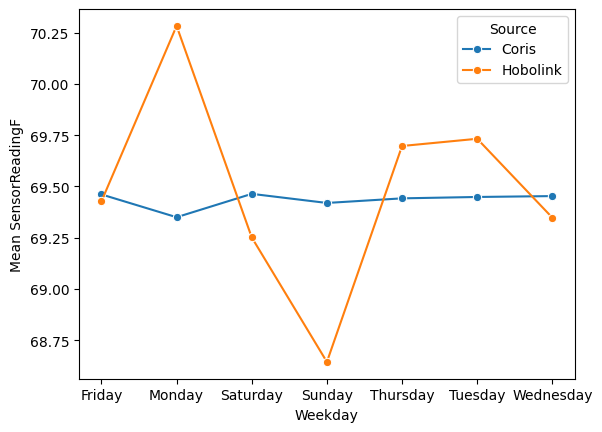

In [8]:
# Example: Average reading by Weekday. 

# join utcs to get weekday. 
# df converts results to a pandas DataFrame.

# use abs(dr.SensorReadingUTC - dr.QueryUTC) < 60 * 5 to remove old sensor readings.

import seaborn as sns

data = duckdb.sql("""
    SELECT day_of_week as Weekday, Source, avg(SensorReadingF) as 'Mean SensorReadingF'
    FROM read_parquet('data/device_readings.parquet') AS dr
    INNER JOIN read_parquet('data/utcs.parquet') AS u ON 
        dr.SensorReadingUTC = u.UTC
    GROUP BY day_of_week, Source
    ORDER BY day_of_week, Source
""").df()

sns.lineplot(x='Weekday', y='Mean SensorReadingF', hue='Source', data=data, marker='o')

<Axes: xlabel='Weekday', ylabel='Mean SensorReadingF'>

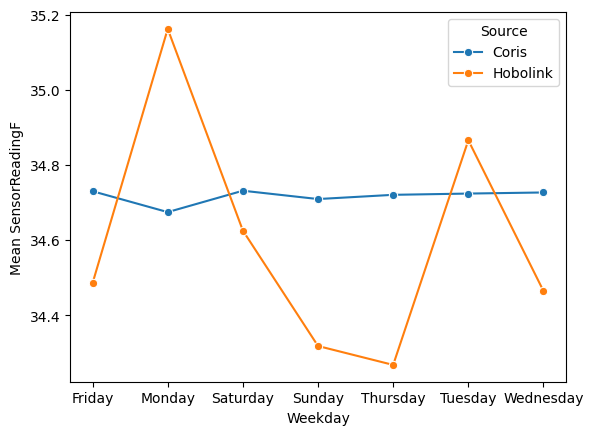

In [12]:
# Example: Average reading by Weekday - using the cubes.

# join utcs to get weekday. 
# df converts results to a pandas DataFrame.

# cubes already have old sensor readings removed. 

import seaborn as sns

data = duckdb.sql("""
    SELECT day_of_week as Weekday, Source, sum(SensorReadingF_sum) / sum(row_count) as 'Mean SensorReadingF'
    FROM read_parquet('data/device_readings_daily.parquet') AS drd
    INNER JOIN (SELECT DISTINCT date, day_of_week FROM read_parquet('data/utcs.parquet')) AS u
        ON drd.date = u.date
    GROUP BY day_of_week, Source
    ORDER BY day_of_week, Source
""").df()

# need DISTINCT on utcs to prevent duplication!

sns.lineplot(x='Weekday', y='Mean SensorReadingF', hue='Source', data=data, marker='o')

In [17]:
# Buildings: Number of Devices, First Reading.

# join utcs to get date. 
# join devices to get building info.
# df converts results to a pandas DataFrame.

duckdb.sql("""
    SELECT dr.Source, Building, min(date) as 'First Reading', count(DISTINCT dr.DeviceID) as 'Count of Devices'
    FROM read_parquet('data/device_readings.parquet') AS dr
    INNER JOIN read_parquet('data/utcs.parquet') AS u
        ON dr.SensorReadingUTC = u.UTC
    INNER JOIN read_parquet('data/devices.parquet') AS d
        ON d.DeviceID = dr.DeviceID
    GROUP BY dr.Source, Building
    ORDER BY min(date)
""").df()

,Source,Building,First Reading,Count of Devices
0,Coris,Kline Geology Laboratory,2023-11-06,1
1,Coris,Yale Peabody Museum,2023-11-06,2
2,Hobolink,Unknown,2024-12-12,3


In [18]:
# Readings that differ from the Query UTC. These could be data errors if the difference is large.
duckdb.sql("""
    SELECT QueryUTC, SensorReadingUTC, (SensorReadingUTC - QueryUTC) / 60 as 'Difference (Minutes)'
    FROM read_parquet('data/sensor_readings.parquet') 
    WHERE abs(SensorReadingUTC - QueryUTC) > 60 * 1
    ORDER BY abs(SensorReadingUTC - QueryUTC) DESC
""").df()

,QueryUTC,SensorReadingUTC,Difference (Minutes)
0,1762366389,1762366078,-5.183333
1,1762366389,1762366078,-5.183333
2,1762366389,1762366242,-2.450000
3,1762366389,1762366242,-2.450000
4,1762366389,1762366274,-1.916667
5,1762366389,1762366274,-1.916667
